# House Price Prediction

This notebook covers **Data Preprocessing** and **Simple Linear Regression** for house price prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Task 1: Data Preprocessing for Machine Learning
### 1.1 Load the Dataset

In [2]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: g:\Projects\CodVeda\machine-learning-models-portfolio\house_price_prediction


In [3]:
# Load dataset from the datasets directory
from pathlib import Path

dataset_path = Path('house_prediction_dataset.csv')

if dataset_path.exists():
    df = pd.read_csv(dataset_path)
else:
    print("Dataset not found! Please add it to the data folder.")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### 1.2 Handle Missing Data

In [4]:
print("Missing values before handling:")
print(df.isnull().sum())

# The original Boston dataset has no missing values, but as a robust preprocessing practice,
# we can fill any possible missing values with the median of their respective columns.
df.fillna(df.median(), inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values before handling:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Missing values after handling:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


### 1.3 Encode Categorical Variables

In [5]:
# The 'CHAS' column is a categorical variable representing the Charles River dummy variable 
# (1 if tract bounds river; 0 otherwise).
# Since it is already encoded as numeric values (0 and 1), one-hot encoding is not strictly necessary.
print("CHAS unique values:", df['CHAS'].unique())

# We will keep it as is. If we had text-based categorical columns (e.g. 'Red', 'Blue'), 
# we would use pd.get_dummies() to one-hot encode them.
print("Dataset shape remains:", df.shape)
df[['CHAS']].head()

CHAS unique values: [0 1]
Dataset shape remains: (506, 14)


,CHAS
0,0
1,0
2,0
3,0
4,0


### 1.4 Split Dataset

In [6]:
# Features (X) and Target (y = MEDV)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

Training features shape: (404, 13)
Testing features shape: (102, 13)


### 1.5 Normalize/Standardize Numerical Features

In [7]:
scaler = StandardScaler()

# Fit on training data and transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Scaled training features preview:")
X_train_scaled.head()

Scaled training features preview:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,1.287702,-0.500320,1.033237,-0.278089,0.489252,-1.428069,1.028015,-0.802173,1.706891,1.578434,0.845343,-0.074337,1.753505
1,-0.336384,-0.500320,-0.413160,-0.278089,-0.157233,-0.680087,-0.431199,0.324349,-0.624360,-0.584648,1.204741,0.430184,-0.561474
2,-0.403253,1.013271,-0.715218,-0.278089,-1.008723,-0.402063,-1.618599,1.330697,-0.974048,-0.602724,-0.637176,0.065297,-0.651595
3,0.388230,-0.500320,1.033237,-0.278089,0.489252,-0.300450,0.591681,-0.839240,1.706891,1.578434,0.845343,-3.868193,1.525387
4,-0.325282,-0.500320,-0.413160,-0.278089,-0.157233,-0.831094,0.033747,-0.005494,-0.624360,-0.584648,1.204741,0.379119,-0.165787


## Task 2: Build a Simple Linear Regression Model
### 2.1 Train a Linear Regression Model

In [8]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Model training complete.")

Model training complete.


### 2.2 Interpret Model Coefficients

In [9]:
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1)

print("Model Intercept (Baseline MEDV):", model.intercept_)
print("\nModel Coefficients:")
print(coefficients)

Model Intercept (Baseline MEDV): 22.796534653465343

Model Coefficients:
    Feature  Coefficient
12    LSTAT    -3.611658
5        RM     3.145240
7       DIS    -3.081908
8       RAD     2.251407
10  PTRATIO    -2.037752
4       NOX    -2.022319
9       TAX    -1.767014
11        B     1.129568
0      CRIM    -1.002135
3      CHAS     0.718738
1        ZN     0.696269
2     INDUS     0.278065
6       AGE    -0.176048


### 2.3 Evaluate the Model

In [10]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Calculate R-squared and MSE
r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)

r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)

print("=== Training Set Performance ===")
print(f"R-squared: {r2_train:.4f}")
print(f"Mean Squared Error (MSE): {mse_train:.4f}")

print("\n=== Testing Set Performance ===")
print(f"R-squared: {r2_test:.4f}")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")

=== Training Set Performance ===
R-squared: 0.7509
Mean Squared Error (MSE): 21.6414

=== Testing Set Performance ===
R-squared: 0.6688
Mean Squared Error (MSE): 24.2911


### 2.4 Visualization

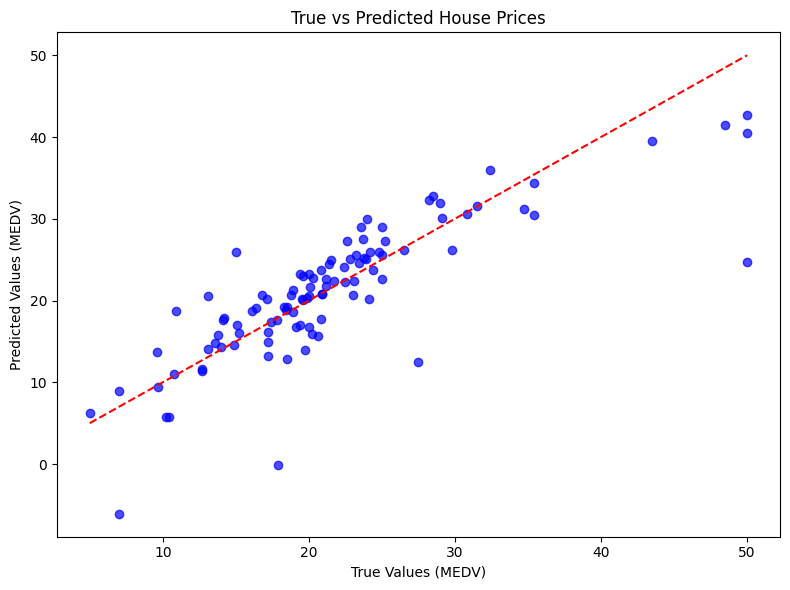

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.7, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('True Values (MEDV)')
plt.ylabel('Predicted Values (MEDV)')
plt.title('True vs Predicted House Prices')
plt.tight_layout()
plt.show()